# RFInject Phase-Aware Mitigation Metrics Evaluation

This notebook validates phase-aware RF mitigation metrics on a synthetic smoke case, then runs the same baseline comparison on one tiny RFInject validation or test burst.

Success criteria:
- the perfect baseline has near-zero score;
- the identity baseline leaves residual RFI energy;
- wrong-phase baselines are penalized by phase MAE and complex coherence;
- clean-region perturbations increase clean-region NMSE;
- padded pixels do not affect any metric.


## Setup

The setup cell is intentionally self-contained: it finds an existing `rfinject-utils` checkout, clones it if missing, switches the notebook process into the repo, installs the editable package with notebook extras, and installs PyTorch if the active kernel does not already provide it.


In [1]:
import importlib
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sirbastiano/rfinject-utils.git"
REPO_NAME = "rfinject-utils"
INSTALL_DEPENDENCIES = True


def run_command(args: list[str], cwd: Path | None = None) -> None:
    print("$", " ".join(str(arg) for arg in args))
    subprocess.run(args, cwd=cwd, check=True)


def ensure_pip() -> None:
    if importlib.util.find_spec("pip") is not None:
        return
    run_command([sys.executable, "-m", "ensurepip", "--upgrade"])
    importlib.invalidate_caches()
    if importlib.util.find_spec("pip") is None:
        raise ModuleNotFoundError("pip is required but could not be bootstrapped with ensurepip.")


def pip_install(args: list[str], cwd: Path | None = None) -> None:
    ensure_pip()
    run_command([sys.executable, "-m", "pip", "install", *args], cwd=cwd)


def find_repo_root(start: Path) -> Path | None:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "rfinject").exists():
            return candidate
    return None


start_dir = Path.cwd().resolve()
repo_root = find_repo_root(start_dir)

if repo_root is None:
    clone_target = start_dir / REPO_NAME
    if not clone_target.exists():
        run_command(["git", "clone", REPO_URL, str(clone_target)])
    repo_root = find_repo_root(clone_target)

if repo_root is None:
    raise FileNotFoundError(f"Could not locate or clone {REPO_NAME}.")

os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Working directory:", Path.cwd())

if INSTALL_DEPENDENCIES:
    pip_install(["-e", ".[jupyter_env]"], cwd=repo_root)
    importlib.invalidate_caches()
    if importlib.util.find_spec("torch") is None:
        pip_install(["torch"], cwd=repo_root)
        importlib.invalidate_caches()


Working directory: /Users/roberto.delprete/Downloads/rfinject-utils
$ /Users/roberto.delprete/Downloads/rfinject-utils/.venv/bin/python -m pip install -e .[jupyter_env]
Obtaining file:///Users/roberto.delprete/Downloads/rfinject-utils
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for rfinject (pyproject.toml): started
  Building editable for rfinject (pyproject.toml): finished with status 'done'
  Created wheel for rfinject: filename=rfinject-0.1.0-py3-none-any.whl size=5996 sha256=ed2c04243dc740dea0bc0798f14ed7dd077906fbf3e


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


## Imports and Configuration

The real-data smoke path defaults to a single scene per split and a 0.1 percent burst payload target. Bursts remain atomic, so the realized download size can be larger than the requested fraction.


In [2]:
import json
import math
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

from rfinject import DEFAULT_HF_BUCKET_ID, list_hf_bucket_zarrs
from rfinject.pytorch_data import (
    RFInjectSplitBurstDataset,
    describe_access_mode,
    pad_burst_batch,
)

torch.manual_seed(7)

catalog_path = repo_root / "src" / "RFInject-full.csv"
cache_dir = repo_root / "data"
output_dir = repo_root / "outputs" / "mitigation_metrics"
cache_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

sample_fraction = 0.001
max_scenes_per_split = 1
batch_size = 1
num_workers = 0
rfi_channel = 0
split_candidates = ("validation", "test")

download_full_scene = False
prefetch_selected_bursts = True
allow_remote_fetch = False

print("Catalog:", catalog_path)
print("Data cache:", cache_dir)
print("Output directory:", output_dir)
print(
    "Access mode:",
    describe_access_mode(
        download_full_scene=download_full_scene,
        prefetch_selected_bursts=prefetch_selected_bursts,
        allow_remote_fetch=allow_remote_fetch,
    ),
)


Catalog: /Users/roberto.delprete/Downloads/rfinject-utils/src/RFInject-full.csv
Data cache: /Users/roberto.delprete/Downloads/rfinject-utils/data
Output directory: /Users/roberto.delprete/Downloads/rfinject-utils/outputs/mitigation_metrics
Access mode: selected bursts cached up front


## Metric Helpers

The helpers operate on complex tensors. RFInject dataloader tensors use `[real, imag]` channels for complex arrays, so `as_complex` converts those into native PyTorch complex tensors first.

Notation: $\hat{x}$ is the mitigation prediction, $x$ is the clean target, $r$ is the injected RFI, $V$ is the valid padding mask, $M_r$ is the RFI mask, and $M_c = V \setminus M_r$ is the clean-region mask. Small denominators are protected by $\epsilon$.

The RFI mask is defined as:

$$
M_r = \{i \in V : |r_i| > \tau\}, \qquad
\tau = \epsilon_{rel}\max_{j \in V}|r_j|
$$

For an arbitrary mask $M$, masked complex NMSE is:

$$
\operatorname{NMSE}_M(\hat{x}, x) =
\frac{\sum_{i \in M}|\hat{x}_i - x_i|^2}{\max\left(\sum_{i \in M}|x_i|^2, \epsilon\right)}
$$

Phase MAE is computed only where both prediction and target have non-zero magnitude:

$$
\operatorname{PhaseMAE}_M(\hat{x}, x) =
\frac{1}{|M'|}\sum_{i \in M'} |\angle(\hat{x}_i x_i^*)|,
\qquad M' = \{i \in M : |\hat{x}_i| > \epsilon, |x_i| > \epsilon\}
$$

`complex_coherence` is the real part of the normalized complex inner product, clipped to `[-1, 1]`. This keeps the metric phase-aware: a fixed phase rotation has lower coherence even when the magnitude is unchanged.

$$
C_M(\hat{x}, x) = \operatorname{clip}_{[-1, 1]}
\left(
\operatorname{Re}\frac{\sum_{i \in M'}\hat{x}_i x_i^*}
{\max\left(\sqrt{\sum_{i \in M'}|\hat{x}_i|^2\sum_{i \in M'}|x_i|^2}, \epsilon\right)}
\right)
$$

Residual RFI energy ratio and magnitude RMSE are:

$$
\operatorname{ResidualRFI}_{M_r} =
\frac{\sum_{i \in M_r}|\hat{x}_i - x_i|^2}{\max\left(\sum_{i \in M_r}|r_i|^2, \epsilon\right)},
\qquad
\operatorname{MagRMSE}_M =
\sqrt{\frac{1}{|M|}\sum_{i \in M}(|\hat{x}_i| - |x_i|)^2}
$$

The notebook ranks baselines with the weighted score:

$$
\operatorname{score} =
0.45\operatorname{NMSE}_{M_r}
+ 0.25\operatorname{NMSE}_{M_c}
+ 0.20\operatorname{PhaseMAE}_{M_r}
+ 0.10(1 - C_{M_r})
$$


In [3]:
EPS = 1e-12


def as_complex(value) -> torch.Tensor:
    tensor = value if torch.is_tensor(value) else torch.as_tensor(value)
    if torch.is_complex(tensor):
        return tensor
    if tensor.ndim >= 3 and tensor.shape[-3] == 2:
        return torch.complex(tensor.select(-3, 0), tensor.select(-3, 1))
    if tensor.ndim >= 3 and tensor.shape[-3] == 1:
        return tensor.select(-3, 0).to(torch.complex64)
    return tensor.to(torch.complex64)


def as_mask(mask, like: torch.Tensor) -> torch.Tensor:
    if mask is None:
        return torch.ones_like(torch.real(like), dtype=torch.bool)
    if torch.is_tensor(mask):
        mask_tensor = mask.to(device=like.device, dtype=torch.bool)
    else:
        mask_tensor = torch.as_tensor(mask, device=like.device, dtype=torch.bool)
    if mask_tensor.ndim == like.ndim + 1 and mask_tensor.shape[-3] == 1:
        mask_tensor = mask_tensor.select(-3, 0)
    return mask_tensor


def _masked_count(mask: torch.Tensor) -> int:
    return int(mask.sum().detach().cpu().item())


def make_rfi_mask(
    rfi,
    valid_mask,
    eps_mode: str = "relative",
    relative_eps: float = 1e-3,
    absolute_eps: float = 0.0,
) -> torch.Tensor:
    rfi_complex = as_complex(rfi)
    valid = as_mask(valid_mask, rfi_complex)
    magnitude = torch.abs(rfi_complex)

    if eps_mode == "relative":
        masked_magnitude = torch.where(valid, magnitude, torch.zeros_like(magnitude))
        scale = masked_magnitude.amax(dim=(-2, -1), keepdim=True).clamp_min(EPS)
        threshold = relative_eps * scale
    elif eps_mode == "absolute":
        threshold = torch.as_tensor(absolute_eps, device=rfi_complex.device, dtype=magnitude.dtype)
    else:
        raise ValueError("eps_mode must be 'relative' or 'absolute'.")

    return (magnitude > threshold) & valid


def complex_nmse(prediction, target, mask) -> float:
    prediction_complex = as_complex(prediction)
    target_complex = as_complex(target)
    selected = as_mask(mask, prediction_complex)
    if _masked_count(selected) == 0:
        return 0.0

    error_energy = torch.abs(prediction_complex - target_complex).pow(2)[selected].sum()
    target_energy = torch.abs(target_complex).pow(2)[selected].sum().clamp_min(EPS)
    return float((error_energy / target_energy).detach().cpu().item())


def phase_mae(prediction, target, mask) -> float:
    prediction_complex = as_complex(prediction)
    target_complex = as_complex(target)
    selected = as_mask(mask, prediction_complex)
    selected = selected & (torch.abs(prediction_complex) > EPS) & (torch.abs(target_complex) > EPS)
    if _masked_count(selected) == 0:
        return 0.0

    phase_error = torch.angle(prediction_complex[selected] * torch.conj(target_complex[selected]))
    return float(torch.abs(phase_error).mean().detach().cpu().item())


def complex_coherence(prediction, target, mask) -> float:
    prediction_complex = as_complex(prediction)
    target_complex = as_complex(target)
    selected = as_mask(mask, prediction_complex)
    selected = selected & (torch.abs(prediction_complex) > EPS) & (torch.abs(target_complex) > EPS)
    if _masked_count(selected) == 0:
        return 1.0

    numerator = (prediction_complex[selected] * torch.conj(target_complex[selected])).sum()
    prediction_energy = torch.abs(prediction_complex[selected]).pow(2).sum()
    target_energy = torch.abs(target_complex[selected]).pow(2).sum()
    denominator = torch.sqrt(prediction_energy * target_energy).clamp_min(EPS)
    coherence = torch.real(numerator / denominator).clamp(-1.0, 1.0)
    return float(coherence.detach().cpu().item())


def residual_rfi_energy_ratio(prediction, clean, rfi, mask) -> float:
    prediction_complex = as_complex(prediction)
    clean_complex = as_complex(clean)
    rfi_complex = as_complex(rfi)
    selected = as_mask(mask, prediction_complex)
    if _masked_count(selected) == 0:
        return 0.0

    residual_energy = torch.abs(prediction_complex - clean_complex).pow(2)[selected].sum()
    rfi_energy = torch.abs(rfi_complex).pow(2)[selected].sum().clamp_min(EPS)
    return float((residual_energy / rfi_energy).detach().cpu().item())


def magnitude_rmse(prediction, target, mask) -> float:
    prediction_complex = as_complex(prediction)
    target_complex = as_complex(target)
    selected = as_mask(mask, prediction_complex)
    if _masked_count(selected) == 0:
        return 0.0

    magnitude_error = torch.abs(prediction_complex) - torch.abs(target_complex)
    return float(torch.sqrt(torch.mean(magnitude_error[selected].pow(2))).detach().cpu().item())


def mitigation_score(prediction, clean, rfi, valid_mask, rfi_mask=None) -> dict[str, float]:
    prediction_complex = as_complex(prediction)
    clean_complex = as_complex(clean)
    rfi_complex = as_complex(rfi)
    valid = as_mask(valid_mask, clean_complex)
    if rfi_mask is None:
        rfi_mask = make_rfi_mask(rfi_complex, valid)
    else:
        rfi_mask = as_mask(rfi_mask, clean_complex) & valid
    clean_region_mask = valid & ~rfi_mask

    masked_complex_nmse = complex_nmse(prediction_complex, clean_complex, rfi_mask)
    clean_region_complex_nmse = complex_nmse(prediction_complex, clean_complex, clean_region_mask)
    phase_mae_rad = phase_mae(prediction_complex, clean_complex, rfi_mask)
    coherence = complex_coherence(prediction_complex, clean_complex, rfi_mask)

    score = (
        0.45 * masked_complex_nmse
        + 0.25 * clean_region_complex_nmse
        + 0.20 * phase_mae_rad
        + 0.10 * (1.0 - coherence)
    )

    return {
        "score": score,
        "masked_complex_nmse": masked_complex_nmse,
        "clean_region_complex_nmse": clean_region_complex_nmse,
        "phase_mae_rad": phase_mae_rad,
        "phase_mae_deg": math.degrees(phase_mae_rad),
        "complex_coherence": coherence,
        "residual_rfi_energy_ratio": residual_rfi_energy_ratio(
            prediction_complex, clean_complex, rfi_complex, rfi_mask
        ),
        "magnitude_rmse": magnitude_rmse(prediction_complex, clean_complex, rfi_mask),
    }


## Baselines

The baseline set includes the four requested comparisons plus one clean-region perturbation used to verify that clean-region NMSE reacts when non-RFI pixels are changed.


In [4]:
def build_baselines(clean, rfi, valid_mask, fixed_phase_offset: float = math.pi / 4):
    clean_complex = as_complex(clean)
    rfi_complex = as_complex(rfi)
    valid = as_mask(valid_mask, clean_complex)
    contaminated = clean_complex + rfi_complex
    rfi_mask = make_rfi_mask(rfi_complex, valid)
    clean_region_mask = valid & ~rfi_mask

    phase_factor = torch.exp(
        torch.as_tensor(1j * fixed_phase_offset, device=clean_complex.device, dtype=clean_complex.dtype)
    )
    clean_region_factor = torch.as_tensor(1.0 + 0.25j, device=clean_complex.device, dtype=clean_complex.dtype)

    baselines = {
        "perfect_clean": clean_complex,
        "identity_contaminated": contaminated,
        "magnitude_only_wrong_phase": torch.polar(torch.abs(clean_complex), torch.angle(contaminated)),
        "phase_shifted_45deg": clean_complex * phase_factor,
        "clean_region_perturbed": torch.where(
            clean_region_mask,
            clean_complex * clean_region_factor,
            clean_complex,
        ),
    }
    return baselines, rfi_mask, clean_region_mask, contaminated


def evaluate_baselines(clean, rfi, valid_mask, fixed_phase_offset: float = math.pi / 4):
    baselines, rfi_mask, clean_region_mask, contaminated = build_baselines(
        clean,
        rfi,
        valid_mask,
        fixed_phase_offset=fixed_phase_offset,
    )
    rows = []
    for baseline_name, baseline_prediction in baselines.items():
        rows.append(
            {
                "baseline": baseline_name,
                **mitigation_score(
                    baseline_prediction,
                    clean,
                    rfi,
                    valid_mask,
                    rfi_mask=rfi_mask,
                ),
            }
        )
    metrics_df = pd.DataFrame(rows).set_index("baseline").sort_values("score")
    return metrics_df, baselines, rfi_mask, clean_region_mask, contaminated


## Synthetic Smoke Test

This path verifies the formulas without downloading RFInject data. The invalid padded region is intentionally filled with large RFI values so the mask check can prove that padding is ignored.


In [5]:
height, width = 32, 48
y, x = torch.meshgrid(
    torch.linspace(-1.0, 1.0, height),
    torch.linspace(-1.0, 1.0, width),
    indexing="ij",
)

amplitude = 1.0 + 0.25 * x + 0.15 * y
phase = 0.7 * x - 0.4 * y
synthetic_clean = (amplitude * torch.exp(1j * phase)).unsqueeze(0).to(torch.complex64)

synthetic_valid_mask = torch.ones((1, height, width), dtype=torch.bool)
synthetic_valid_mask[:, -4:, -6:] = False

synthetic_rfi = torch.zeros_like(synthetic_clean)
rfi_region = ((x > -0.2) & (x < 0.35) & (y > -0.65) & (y < 0.55)).unsqueeze(0)
synthetic_rfi[rfi_region] = (
    0.8 * torch.exp(1j * (3.0 * x[rfi_region[0]] + 0.5))
).to(torch.complex64)
synthetic_rfi[~synthetic_valid_mask] = torch.as_tensor(1000.0 - 1000.0j, dtype=torch.complex64)

synthetic_df, synthetic_predictions, synthetic_rfi_mask, synthetic_clean_region_mask, synthetic_contaminated = evaluate_baselines(
    synthetic_clean,
    synthetic_rfi,
    synthetic_valid_mask,
)

display(synthetic_df.round(6))
print("RFI pixels:", int(synthetic_rfi_mask.sum()))
print("Clean-region pixels:", int(synthetic_clean_region_mask.sum()))


,score,masked_complex_nmse,clean_region_complex_nmse,phase_mae_rad,phase_mae_deg,complex_coherence,residual_rfi_energy_ratio,magnitude_rmse
baseline,,,,,,,,
perfect_clean,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000
clean_region_perturbed,0.015625,0.000000,0.062500,0.000000,0.000000,1.000000,0.000000,0.00000
magnitude_only_wrong_phase,0.108490,0.106987,0.000000,0.274982,15.755327,0.946506,0.171641,0.00000
identity_contaminated,0.340850,0.623323,0.000000,0.274982,15.755327,0.946413,1.000000,0.68631
phase_shifted_45deg,0.596419,0.585786,0.585786,0.785398,45.000008,0.707107,0.939780,0.00000


RFI pixels: 247
Clean-region pixels: 1265


## Synthetic Acceptance Checks

The assertions below are the smoke gates for the metric definitions.


In [6]:
perfect = synthetic_df.loc["perfect_clean"]
identity = synthetic_df.loc["identity_contaminated"]
phase_shifted = synthetic_df.loc["phase_shifted_45deg"]
clean_perturbed = synthetic_df.loc["clean_region_perturbed"]

assert perfect["score"] < 1e-8, perfect
assert identity["masked_complex_nmse"] > perfect["masked_complex_nmse"] + 1e-6
assert identity["residual_rfi_energy_ratio"] > 0.5
assert phase_shifted["phase_mae_rad"] > perfect["phase_mae_rad"] + 0.5
assert phase_shifted["complex_coherence"] < perfect["complex_coherence"] - 0.05
assert clean_perturbed["clean_region_complex_nmse"] > perfect["clean_region_complex_nmse"] + 1e-6

dirty_clean = synthetic_clean.clone()
dirty_rfi = synthetic_rfi.clone()
dirty_clean[~synthetic_valid_mask] = torch.as_tensor(-999.0 + 333.0j, dtype=torch.complex64)
dirty_rfi[~synthetic_valid_mask] = torch.as_tensor(777.0 - 555.0j, dtype=torch.complex64)
dirty_df, *_ = evaluate_baselines(dirty_clean, dirty_rfi, synthetic_valid_mask)
pd.testing.assert_frame_equal(
    synthetic_df.sort_index(),
    dirty_df.sort_index(),
    check_exact=False,
    rtol=1e-6,
    atol=1e-6,
)

print("Synthetic metric checks passed.")


Synthetic metric checks passed.


## Real RFInject Burst

This section follows the PyTorch dataloader notebook: `src/RFInject-full.csv` provides split labels, Hugging Face bucket entries are matched to child products, and `RFInjectSplitBurstDataset` loads one validation or test batch.


In [7]:
def parse_child_products(raw_value: str) -> list[str]:
    if pd.isna(raw_value) or raw_value == "":
        return []
    return [f"{child}.zarr" for child in json.loads(raw_value)]


catalog_df = pd.read_csv(catalog_path)
split_column = "Split"
geo_section_column = "GeoSection"
required_columns = {"Name", "ChildProducts", geo_section_column, split_column}
missing_columns = required_columns.difference(catalog_df.columns)
if missing_columns:
    raise KeyError(f"Missing required catalog columns: {sorted(missing_columns)}")

bucket_scene_paths = set(list_hf_bucket_zarrs(DEFAULT_HF_BUCKET_ID))
split_scene_entries = {split_name: [] for split_name in split_candidates}
catalog_child_counts = {split_name: 0 for split_name in split_candidates}

for split_name in split_candidates:
    split_rows = catalog_df.loc[catalog_df[split_column] == split_name]
    for row in split_rows.itertuples(index=False):
        child_scene_paths = parse_child_products(row.ChildProducts)
        catalog_child_counts[split_name] += len(child_scene_paths)
        for scene_path in child_scene_paths:
            if scene_path in bucket_scene_paths:
                split_scene_entries[split_name].append(
                    {
                        "scene_path": scene_path,
                        "geo_section": getattr(row, geo_section_column),
                        "parent_name": row.Name,
                    }
                )

for split_name, scene_entries in split_scene_entries.items():
    unique_scene_entries = {}
    for entry in scene_entries:
        unique_scene_entries[entry["scene_path"]] = entry
    ordered_entries = [
        unique_scene_entries[scene_path]
        for scene_path in sorted(unique_scene_entries)
    ]
    if max_scenes_per_split is not None:
        ordered_entries = ordered_entries[:max_scenes_per_split]
    split_scene_entries[split_name] = ordered_entries

real_split = next(
    (split_name for split_name in split_candidates if split_scene_entries[split_name]),
    None,
)
if real_split is None:
    raise RuntimeError(f"No bucket-available scenes were found for splits: {split_candidates}")

dataset = RFInjectSplitBurstDataset(
    split_scene_entries[real_split],
    split_name=real_split,
    cache_dir=cache_dir,
    download_full_scene=download_full_scene,
    prefetch_selected_bursts=prefetch_selected_bursts,
    allow_remote_fetch=allow_remote_fetch,
    sample_fraction=sample_fraction,
    rfi_channel=rfi_channel,
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=pad_burst_batch,
)

batch = next(iter(loader))

echo = as_complex(batch["echo"])
rfi = as_complex(batch["rfi"])
valid_mask = batch["echo_mask"] & batch["rfi_mask"]
clean = echo
contaminated = echo + rfi


def baseline(contaminated_tensor):
    return contaminated_tensor


prediction = baseline(contaminated)

print("Selected split:", real_split)
print("Scene:", batch["scene_path"][0])
print("Burst:", batch["burst_name"][0])
print("Echo shape:", tuple(batch["echo"].shape))
print("RFI shape:", tuple(batch["rfi"].shape))
print("Valid pixels:", int(valid_mask.sum()))
print("Dataset bursts:", len(dataset))


Selected split: validation
Scene: s1a-iw-raw-s-vh-20211012t204336-20211012t204408-040091-04bf46.zarr
Burst: burst_0
Echo shape: (1, 2, 1017, 19654)
RFI shape: (1, 2, 1017, 19654)
Valid pixels: 19988118
Dataset bursts: 1


## Real-Burst Baseline Metrics

The same baseline suite is evaluated against the real burst. Lower score is better.


In [8]:
real_df, real_predictions, real_rfi_mask, real_clean_region_mask, real_contaminated = evaluate_baselines(
    clean,
    rfi,
    valid_mask,
)

display(real_df.round(6))

assert real_df.loc["perfect_clean", "score"] < 1e-8
assert real_df.loc["identity_contaminated", "residual_rfi_energy_ratio"] > 0.5
assert real_df.loc["phase_shifted_45deg", "phase_mae_rad"] > real_df.loc["perfect_clean", "phase_mae_rad"]
assert real_df.loc["phase_shifted_45deg", "complex_coherence"] < real_df.loc["perfect_clean", "complex_coherence"]
assert real_df.loc["clean_region_perturbed", "clean_region_complex_nmse"] > real_df.loc["perfect_clean", "clean_region_complex_nmse"]

print("Real-burst metric checks passed.")


,score,masked_complex_nmse,clean_region_complex_nmse,phase_mae_rad,phase_mae_deg,complex_coherence,residual_rfi_energy_ratio,magnitude_rmse
baseline,,,,,,,,
perfect_clean,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
clean_region_perturbed,0.015625,0.000000,0.062500,0.000000,0.000000,1.000000,0.000000,0.000000
phase_shifted_45deg,0.596419,0.585786,0.585786,0.785398,45.000015,0.707107,0.031123,0.000000
magnitude_only_wrong_phase,0.842947,1.217683,0.000000,1.170527,67.066229,0.391159,0.064695,0.000000
identity_contaminated,8.781476,18.821808,0.000000,1.170527,67.066229,0.224428,1.000000,21.510853


Real-burst metric checks passed.


## Preview Plot

The preview shows one burst: clean magnitude, contaminated magnitude, RFI magnitude, RFI mask, and error maps for representative baselines.


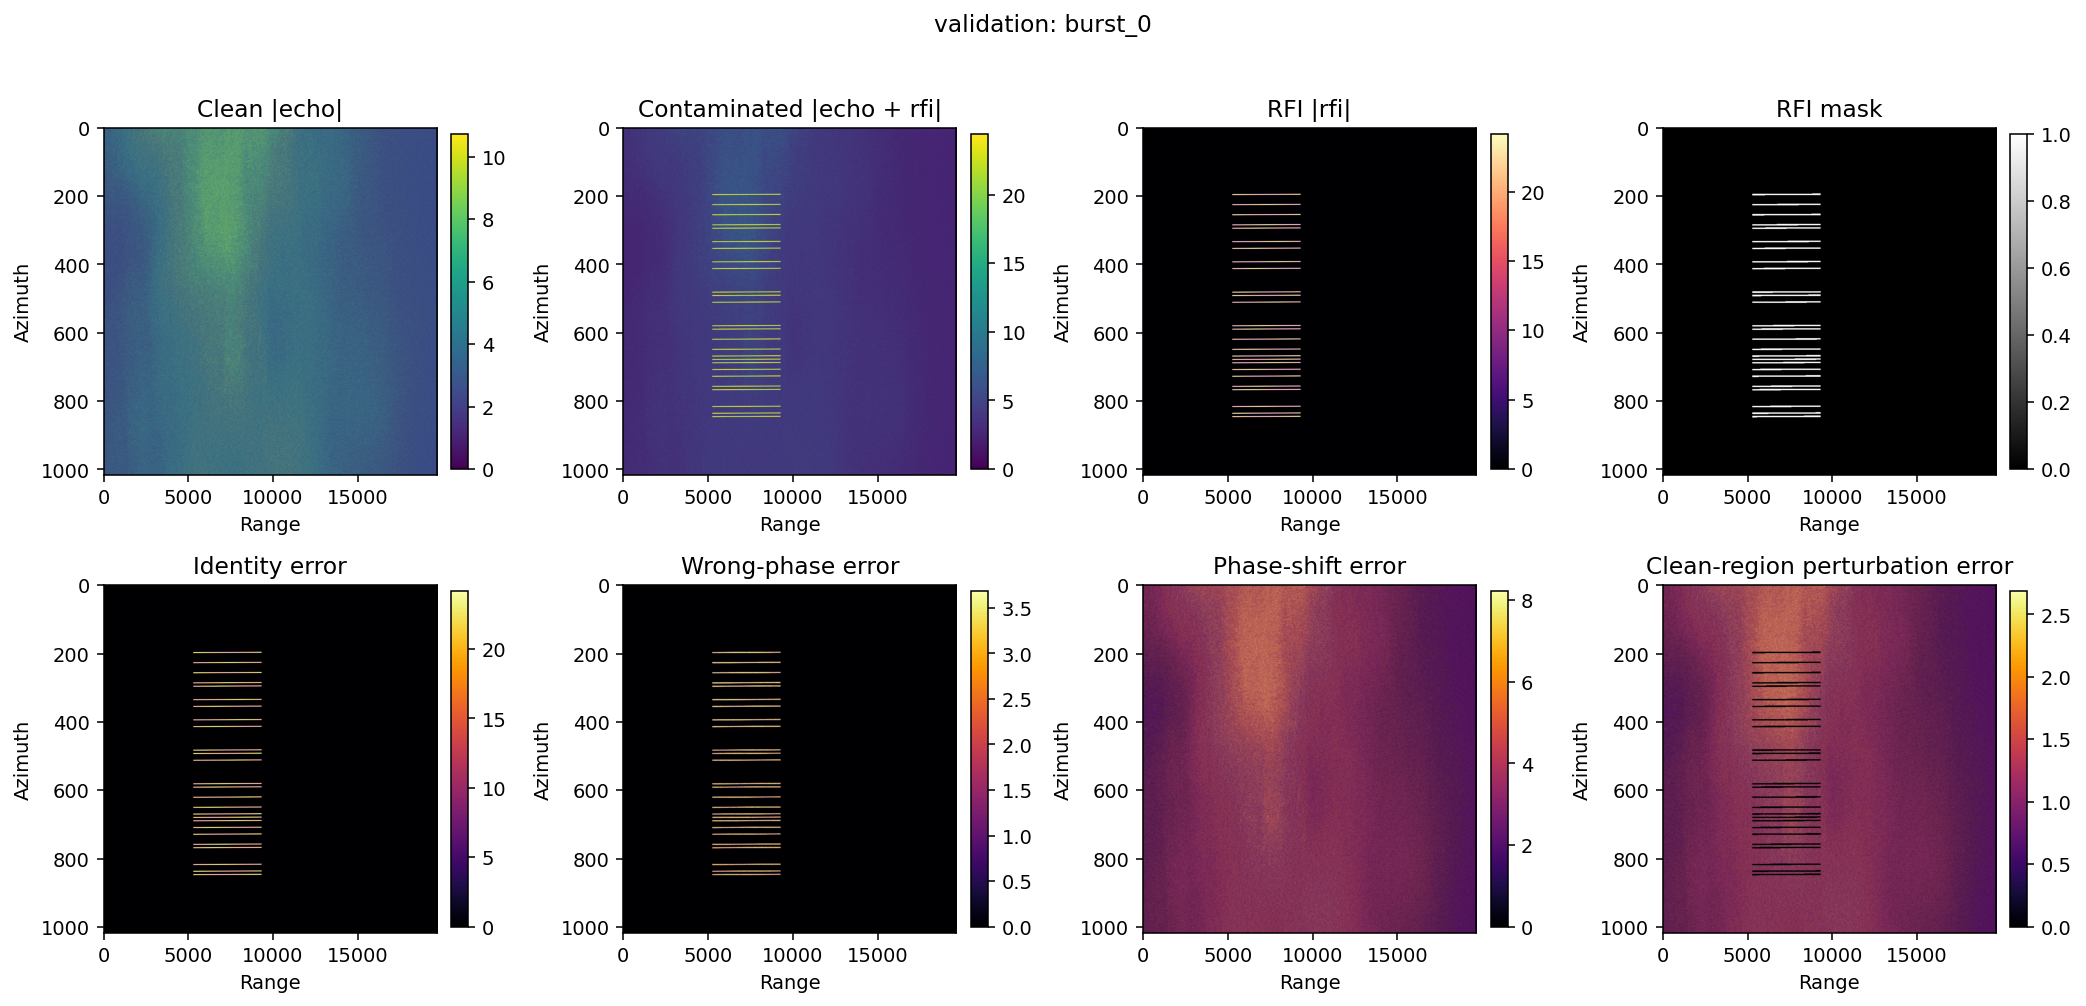

Saved preview: /Users/roberto.delprete/Downloads/rfinject-utils/outputs/mitigation_metrics/metric_demo_preview.png


In [9]:
def image_from_complex(value, sample_idx: int = 0, valid=None):
    array = torch.abs(as_complex(value)[sample_idx]).detach().cpu().numpy()
    if valid is not None:
        valid_array = valid[sample_idx].detach().cpu().numpy().astype(bool)
        array = np.where(valid_array, array, np.nan)
    return array


def error_image(prediction_value, target_value, sample_idx: int = 0, valid=None):
    array = torch.abs(as_complex(prediction_value)[sample_idx] - as_complex(target_value)[sample_idx]).detach().cpu().numpy()
    if valid is not None:
        valid_array = valid[sample_idx].detach().cpu().numpy().astype(bool)
        array = np.where(valid_array, array, np.nan)
    return array


plot_items = [
    ("Clean |echo|", image_from_complex(clean, valid=valid_mask), "viridis"),
    ("Contaminated |echo + rfi|", image_from_complex(real_contaminated, valid=valid_mask), "viridis"),
    ("RFI |rfi|", image_from_complex(rfi, valid=valid_mask), "magma"),
    ("RFI mask", real_rfi_mask[0].detach().cpu().numpy().astype(float), "gray"),
    (
        "Identity error",
        error_image(real_predictions["identity_contaminated"], clean, valid=valid_mask),
        "inferno",
    ),
    (
        "Wrong-phase error",
        error_image(real_predictions["magnitude_only_wrong_phase"], clean, valid=valid_mask),
        "inferno",
    ),
    (
        "Phase-shift error",
        error_image(real_predictions["phase_shifted_45deg"], clean, valid=valid_mask),
        "inferno",
    ),
    (
        "Clean-region perturbation error",
        error_image(real_predictions["clean_region_perturbed"], clean, valid=valid_mask),
        "inferno",
    ),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7), dpi=140)
for axis, (title, image, cmap) in zip(axes.ravel(), plot_items, strict=True):
    finite_values = image[np.isfinite(image)]
    vmax = np.nanpercentile(finite_values, 99) if finite_values.size else 1.0
    if vmax <= 0:
        vmax = 1.0
    im = axis.imshow(image, aspect="auto", cmap=cmap, vmin=0, vmax=vmax)
    axis.set_title(title)
    axis.set_xlabel("Range")
    axis.set_ylabel("Azimuth")
    fig.colorbar(im, ax=axis, fraction=0.046, pad=0.04)

fig.suptitle(f"{real_split}: {batch['burst_name'][0]}", y=1.02)
fig.tight_layout()
preview_path = output_dir / "metric_demo_preview.png"
fig.savefig(preview_path, bbox_inches="tight")
plt.show()
print("Saved preview:", preview_path)


## Save Artifacts

Metrics and metadata are written under `outputs/mitigation_metrics/`.


In [10]:
comparison_path = output_dir / "baseline_metric_comparison.csv"
summary_path = output_dir / "baseline_metric_summary.json"

real_df.to_csv(comparison_path)

summary = {
    "repo_root": str(repo_root),
    "catalog_path": str(catalog_path),
    "split": real_split,
    "scene_path": batch["scene_path"][0],
    "burst_name": batch["burst_name"][0],
    "sample_fraction": sample_fraction,
    "max_scenes_per_split": max_scenes_per_split,
    "batch_size": batch_size,
    "rfi_channel": rfi_channel,
    "valid_pixels": int(valid_mask.sum()),
    "rfi_pixels": int(real_rfi_mask.sum()),
    "score_formula": (
        "0.45 * masked_complex_nmse + "
        "0.25 * clean_region_complex_nmse + "
        "0.20 * phase_mae + "
        "0.10 * (1 - complex_coherence)"
    ),
    "metrics": json.loads(real_df.to_json(orient="index")),
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
    f.write("\n")

print("Saved metrics:", comparison_path)
print("Saved summary:", summary_path)
print("Saved preview:", preview_path)


Saved metrics: /Users/roberto.delprete/Downloads/rfinject-utils/outputs/mitigation_metrics/baseline_metric_comparison.csv
Saved summary: /Users/roberto.delprete/Downloads/rfinject-utils/outputs/mitigation_metrics/baseline_metric_summary.json
Saved preview: /Users/roberto.delprete/Downloads/rfinject-utils/outputs/mitigation_metrics/metric_demo_preview.png


## Notes

The metric helpers are kept in the notebook for review. Once the formulas are accepted, the same functions can be promoted into a package module such as `rfinject/metrics.py` and covered with focused unit tests.
